<a href="https://colab.research.google.com/github/jeevankumar-glitch/CHINTU-/blob/main/X_RAY_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

X-RAY INTELLIGENT ANALYST
Device: cpu

Upload your X-ray image.


Saving images (2).jpg to images (2).jpg

Uploaded file: images (2).jpg


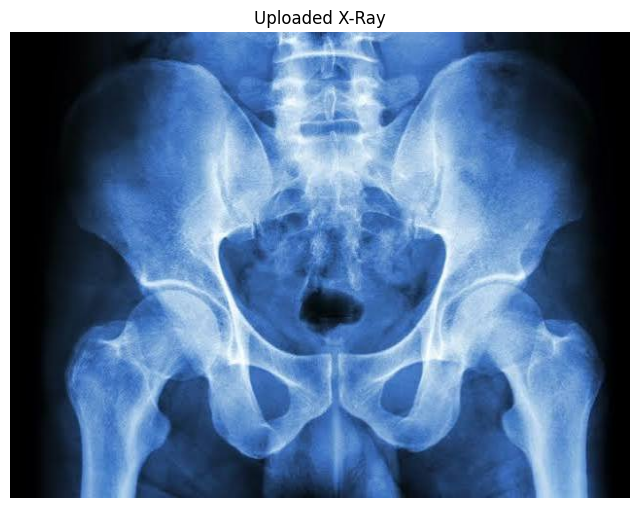


Image loaded successfully!
Image size: (638, 480)


In [14]:
# ============================================================
# X-RAY INTELLIGENT ANALYST
# SETUP + IMAGE UPLOAD
# ============================================================

# Install required packages
!pip -q install transformers accelerate sentencepiece

# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from google.colab import files

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import models, transforms

from transformers import AutoTokenizer, AutoModel

from datetime import datetime


# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("========================================")
print("X-RAY INTELLIGENT ANALYST")
print("========================================")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# UPLOAD IMAGE
# ============================================================

print("\nUpload your X-ray image.")

uploaded = files.upload()


# Check whether an image was uploaded
if len(uploaded) == 0:
    raise RuntimeError("No file was uploaded.")


# Get uploaded filename
image_path = list(uploaded.keys())[0]

print("\nUploaded file:", image_path)


# ============================================================
# OPEN IMAGE
# ============================================================

try:

    image = Image.open(image_path).convert("RGB")

except Exception as e:

    raise RuntimeError(
        f"Could not open the uploaded image: {e}"
    )


# ============================================================
# DISPLAY IMAGE
# ============================================================

plt.figure(figsize=(8, 8))

plt.imshow(image)

plt.axis("off")

plt.title("Uploaded X-Ray")

plt.show()


print("\nImage loaded successfully!")
print("Image size:", image.size)

In [15]:
# ============================================================
# CNN FEATURE EXTRACTOR
# ============================================================

image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# Convert image to tensor
image_tensor = image_transform(image)

# Add batch dimension
image_tensor = image_tensor.unsqueeze(0)

# Move to GPU/CPU
image_tensor = image_tensor.to(device)


print("Input shape:", image_tensor.shape)


# Load pretrained ResNet18
cnn = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)


# Remove classification layer
cnn.fc = nn.Identity()

cnn = cnn.to(device)

cnn.eval()


# Extract features
with torch.no_grad():

    image_features = cnn(image_tensor)


print("CNN feature shape:", image_features.shape)

Input shape: torch.Size([1, 3, 224, 224])
CNN feature shape: torch.Size([1, 512])


In [16]:
# ============================================================
# TRANSFORMER
# ============================================================

MODEL_NAME = "distilbert-base-uncased"


print("Loading Transformer...")

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

transformer = AutoModel.from_pretrained(
    MODEL_NAME
)

transformer = transformer.to(device)

transformer.eval()

print("Transformer loaded successfully!")

Loading Transformer...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Transformer loaded successfully!


In [17]:
# ============================================================
# MEDICAL REPORT
# ============================================================

report_text = input(
    "Enter the X-ray report/clinical notes "
    "(or press Enter to skip): "
)


if report_text.strip() == "":

    report_text = "No medical report provided."


print("\nReport:")
print(report_text)

Enter the X-ray report/clinical notes (or press Enter to skip): 

Report:
No medical report provided.


In [18]:
# ============================================================
# TRANSFORMER TEXT FEATURES
# ============================================================

text_inputs = tokenizer(
    report_text,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=256
)


text_inputs = {
    key: value.to(device)
    for key, value in text_inputs.items()
}


with torch.no_grad():

    transformer_output = transformer(
        **text_inputs
    )

    text_features = (
        transformer_output
        .last_hidden_state[:, 0, :]
    )


print(
    "Transformer feature shape:",
    text_features.shape
)

Transformer feature shape: torch.Size([1, 768])


In [19]:
# ============================================================
# LSTM / RNN
# ============================================================

class TemporalLSTM(nn.Module):

    def __init__(
        self,
        input_size=768,
        hidden_size=256,
        num_layers=2
    ):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )


    def forward(self, x):

        output, (hidden, cell) = self.lstm(x)

        return hidden[-1]


lstm_model = TemporalLSTM().to(device)

lstm_model.eval()


# Create demo temporal sequence
history_tensor = torch.zeros(
    1,
    1,
    768
).to(device)


with torch.no_grad():

    temporal_features = lstm_model(
        history_tensor
    )


print(
    "LSTM feature shape:",
    temporal_features.shape
)

LSTM feature shape: torch.Size([1, 256])


In [20]:
# ============================================================
# MULTIMODAL FUSION
# ============================================================

class MultimodalFusion(nn.Module):

    def __init__(
        self,
        cnn_dim=512,
        lstm_dim=256,
        text_dim=768,
        hidden_dim=512,
        num_classes=4
    ):

        super().__init__()

        self.fusion = nn.Sequential(

            nn.Linear(
                cnn_dim + lstm_dim + text_dim,
                hidden_dim
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                hidden_dim,
                256
            ),

            nn.ReLU(),

            nn.Linear(
                256,
                num_classes
            )
        )


    def forward(
        self,
        image_features,
        temporal_features,
        text_features
    ):

        combined = torch.cat(
            [
                image_features,
                temporal_features,
                text_features
            ],
            dim=1
        )

        return self.fusion(combined)


fusion_model = MultimodalFusion().to(device)

fusion_model.eval()


# ============================================================
# RUN FUSION
# ============================================================

with torch.no_grad():

    output = fusion_model(
        image_features,
        temporal_features,
        text_features
    )


probabilities = F.softmax(
    output,
    dim=1
)


print("Fusion output:")
print(probabilities.cpu().numpy())

Fusion output:
[[0.24062766 0.2681107  0.2620553  0.22920628]]
